<a href="https://colab.research.google.com/github/ianelgar40/IansMIS433/blob/main/Copy_of_text_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Analytics

Text analytics turns unstructured language into data that can be counted, compared, visualized, and modeled. Unlike many tabular datasets, text is high-dimensional: a single column of comments, reviews, emails, or news articles can contain thousands of unique words, phrases, spellings, and meanings.

The main challenge is representation. Before we can summarize or model text, we need to decide how to convert language into numeric features while preserving enough meaning for the task. In this notebook, we will practice common steps in that workflow: cleaning and exploring text, converting text to document-term matrices, finding frequent words, measuring word importance with TF-IDF, clustering similar documents, creating word clouds, and estimating sentiment.

# Load and explore data from csv

Source: https://www.kaggle.com/datasets/cloudy17/bob-dylan-songs/

**Context**
This dataset contains songs from years between 1961 to 2020 written by Bob Dylan.

**Content**
There are 4 columns:
* release_year - year when song was released first time,
* album - name of the album where track occurs,
* title - title of the song,
* lyrics - lyrics of the track

In [1]:
import pandas as pd

# load dataset from csv
df = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/bob-dylan.csv')
df.head(3) # show the first three rows

,release_year,album,title,lyrics
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to..."
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ..."
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...


In [2]:
# shape of the df: rows and columns
df.shape

(345, 4)

In [3]:
# the data types of each column
df.dtypes

,0
release_year,int64
album,object
title,object
lyrics,object


In [4]:
# Get a summary of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   release_year  345 non-null    int64 
 1   album         345 non-null    object
 2   title         345 non-null    object
 3   lyrics        345 non-null    object
dtypes: int64(1), object(3)
memory usage: 10.9+ KB


In [5]:
# Count the values of a column
df.release_year.value_counts()

,count
release_year,
1975,30
1965,22
1963,22
1964,21
1970,19
1966,15
1967,13
1981,13
1983,13


In [6]:
df.album.value_counts()

,count
album,
"The Bootleg Series, Vol 1-3: Rare & Unreleased 1961-1991",37
The Basement Tapes,16
The Freewheelin',13
Blonde on Blonde,13
New Morning,12
John Wesley Harding,12
“Love and Theft”,12
Bringing It All Back Home,11
Under the Red Sky,10


In [7]:
# Add a new column
df['decade'] = (df['release_year'] // 10) * 10
df.head()

,release_year,album,title,lyrics,decade
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to...",1960
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ...",1960
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...,1960
3,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Let Me Die in My Footsteps,I will not go down under the ground\n\n’Cause ...,1960
4,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...","Rambling, Gambling Willie",Come around you rovin’ gamblers and a story I ...,1960


In [8]:
# String Operations
# Count the number of words in each song.

df['word_count'] = df['lyrics'].apply(lambda x: len(x.split()))
df.head()

,release_year,album,title,lyrics,decade,word_count
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to...",1960,353
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ...",1960,158
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...,1960,391
3,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Let Me Die in My Footsteps,I will not go down under the ground\n\n’Cause ...,1960,365
4,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...","Rambling, Gambling Willie",Come around you rovin’ gamblers and a story I ...,1960,477


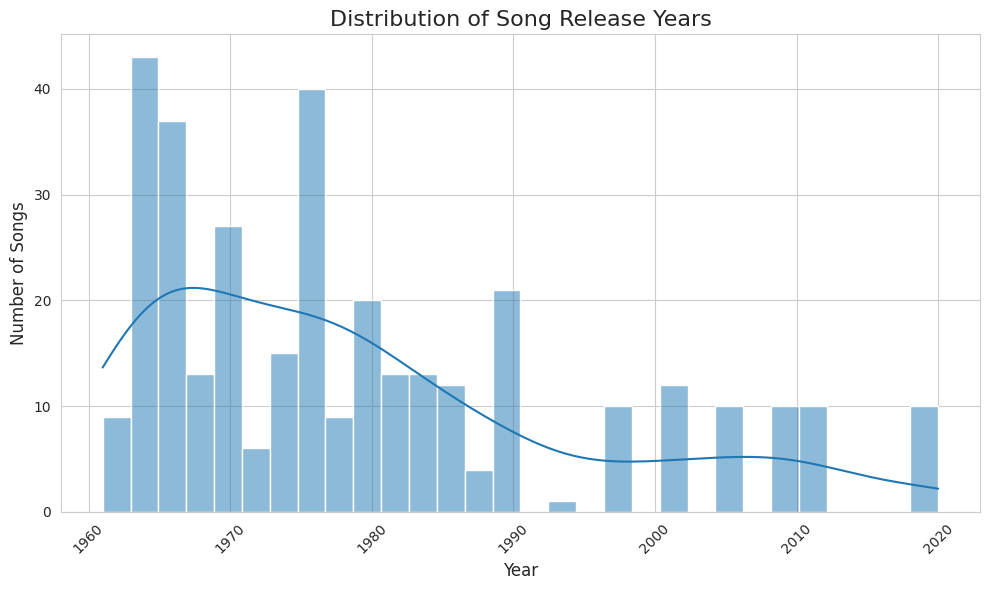

In [9]:
# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid') # Set a prettier style

plt.figure(figsize=(10, 6)) # Adjust figure size for better readability
sns.histplot(df['release_year'], bins=30, kde=True) # Use seaborn's histplot with kde for density estimate
plt.title('Distribution of Song Release Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Songs', fontsize=12)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

## scikit-learn

Scikit-learn is one of the most popular Python packages for predictive data analysis. It includes tools for preprocessing text, building feature matrices, clustering documents, and training machine learning models.

https://scikit-learn.org/

If scikit-learn is not installed in your environment, uncomment and run the next cell.

In [10]:
# !pip install scikit-learn

!pip install scikit-learn


### Vectorization: Converting Text to Numeric Form

Text data must be converted into a numeric form before it can be used with machine learning algorithms. A common technique is `CountVectorizer`, which converts a collection of documents into a document-term matrix. Each row is a document, each column is a token, and each value is the number of times that token appears in that document.

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

# Example using the 'lyrics' column of the Bob Dylan dataset
corpus = df['lyrics'].dropna().tolist()  # Assuming df is your DataFrame and dropping any missing values
vectorizer = CountVectorizer(stop_words='english')  # Remove common 'stop words'
X = vectorizer.fit_transform(corpus)

print(X.shape)  # Shows the shape of the matrix


(345, 7326)


In [12]:
# X is a sparse matrix (csr_matrix), not a pandas DataFrame.
# Sparse matrices do not have a `.head()` method.
# To view the first few rows and their associated feature names,
# we can convert a slice of the sparse matrix to a dense array and then to a DataFrame.

import pandas as pd

# Get the feature names (words) from the vectorizer
feature_names = vectorizer.get_feature_names_out()

# Convert the first 5 rows of the sparse matrix to a dense NumPy array.
# Using .toarray() on the full matrix can be memory-intensive for very large matrices,
# so we only convert a slice here.
first_5_rows_dense = X[:5].toarray()

# Create a Pandas DataFrame from these rows for a readable display
df_X_head = pd.DataFrame(first_5_rows_dense, columns=feature_names)

print("Displaying the first 5 rows of the vectorized data (converted to DataFrame for readability):")
display(df_X_head)

# You can also just check the type and shape of X:
print(f"\nType of X: {type(X)}")
print(f"Shape of X: {X.shape}")

Displaying the first 5 rows of the vectorized data (converted to DataFrame for readability):


,100,101,102,14,14th,15,16,17,18,19,...,youth,youthful,yuh,yul,zanzinger,zapruder,zero,zhukov,zimmy,zone
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Type of X: <class 'scipy.sparse._csr.csr_matrix'>
Shape of X: (345, 7326)


In [13]:
# Accessing the Vocabulary
vocabulary = vectorizer.vocabulary_

# Print the vocabulary dictionary (word: column index)
print(vocabulary)

{'come': 1220, 'ladies': 3508, 'gentlemen': 2630, 'listen': 3691, 'song': 5938, 'sing': 5777, 'right': 5267, 'think': 6491, 'wrong': 7278, 'just': 3423, 'little': 3698, 'glimpse': 2681, 'story': 6172, 'll': 3707, 'tell': 6439, 'bout': 662, 'east': 1989, 'coast': 1182, 'city': 1111, 'know': 3492, 'hard': 2896, 'times': 6558, 'livin': 3704, 'new': 4247, 'york': 7313, 'town': 6627, 'old': 4352, 'friendly': 2531, 'washington': 7031, 'heights': 2981, 'harlem': 2902, 'mighty': 4008, 'people': 4601, 'millin': 4015, 'kick': 3443, 'knock': 3484, 'long': 3731, 'ways': 7056, 'golden': 2706, 'gate': 2605, 'rockefeller': 5321, 'plaza': 4741, 'empire': 2045, 'state': 6108, 'mister': 4055, 'sets': 5607, 'high': 3011, 'bird': 501, 'says': 5488, 'word': 7229, 'country': 1373, 'mornin': 4113, 'tryin': 6734, 'job': 3371, 'work': 7232, 'stand': 6079, 'place': 4706, 'till': 6552, 'feet': 2270, 'begin': 438, 'hurt': 3161, 'got': 2727, 'lot': 3760, 'money': 4084, 'make': 3847, 'merry': 3984, 'nickel': 4256, 

In [14]:
# Size of the vocabulary
len(vocabulary)

7326

In [15]:
# View the first document's feature vector
document_index = 0
feature_vector_sparse = X.getrow(document_index)

# To convert to a dense array
feature_vector_dense = feature_vector_sparse.toarray()

print(feature_vector_dense)

[[0 0 0 ... 0 0 0]]


In [16]:
# To View as a Readable Format

# Get feature names
feature_words = vectorizer.get_feature_names_out()

# Convert the sparse matrix row to a dense array
feature_vector_array = feature_vector_sparse.toarray().flatten()

# Create a dictionary mapping feature names to their values for the document
document_features = {feature_words[i]: int(feature_vector_array[i])
                     for i in range(len(feature_words)) if feature_vector_array[i] != 0}

print(document_features)

{'ay': 1, 'beat': 1, 'begin': 1, 'bird': 1, 'bit': 1, 'bought': 1, 'bout': 1, 'cal': 1, 'caves': 1, 'city': 9, 'cleaner': 1, 'coast': 1, 'come': 2, 'country': 1, 'dirt': 1, 'dream': 1, 'dust': 1, 'east': 1, 'empire': 2, 'feet': 2, 'ferry': 1, 'friendly': 1, 'gate': 1, 'gentlemen': 1, 'glimpse': 1, 'golden': 1, 'got': 2, 'hard': 7, 'harlem': 1, 'heights': 1, 'high': 1, 'hudson': 1, 'hurt': 1, 'island': 1, 'job': 1, 'just': 1, 'kick': 1, 'kind': 1, 'knock': 1, 'know': 1, 'ladies': 1, 'leave': 1, 'listen': 3, 'little': 1, 'livin': 7, 'll': 4, 'long': 1, 'lot': 1, 'make': 1, 'merry': 1, 'mighty': 2, 'millin': 1, 'mines': 1, 'minuet': 1, 'mister': 4, 'money': 1, 'mornin': 1, 'mountain': 1, 'ne': 1, 'new': 10, 'news': 1, 'newsy': 1, 'nickel': 1, 'oklahoma': 1, 'old': 4, 'paid': 1, 'people': 2, 'place': 1, 'plains': 1, 'plaza': 1, 'right': 2, 'rockefeller': 2, 'rocky': 1, 'sailin': 1, 'says': 1, 'sell': 1, 'sets': 1, 'sing': 1, 'smog': 1, 'song': 2, 'spread': 1, 'stand': 1, 'standin': 1, 'sta

In [17]:
# Getting the Most Frequent Words

import numpy as np

# Sum up the counts of each word across all documents
word_counts = np.sum(X.toarray(), axis=0)  # X is the result of vectorizer.fit_transform(corpus)

# Map from feature index to word
feature_words = vectorizer.get_feature_names_out()

# Combine counts and words into a dictionary, ensuring counts are Python integers
word_count_dict = {word: int(count) for word, count in zip(feature_words, word_counts)}

# Sort the dictionary by counts in descending order to get the most frequent words
sorted_word_count = sorted(word_count_dict.items(), key=lambda x: x[1], reverse=True)

# Print the top N most frequent words
top_n_words = 20  # You can adjust N as needed
print(sorted_word_count[:top_n_words])

[('don', 553), ('like', 496), ('just', 477), ('got', 465), ('ll', 451), ('know', 418), ('love', 301), ('gonna', 296), ('man', 287), ('time', 273), ('ve', 273), ('ain', 271), ('said', 265), ('come', 253), ('say', 252), ('oh', 241), ('tell', 219), ('baby', 207), ('way', 195), ('day', 192)]


/tmp/ipykernel_1858/531371955.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Word', y='Count', data=most_frequent_words_df, palette='viridis')


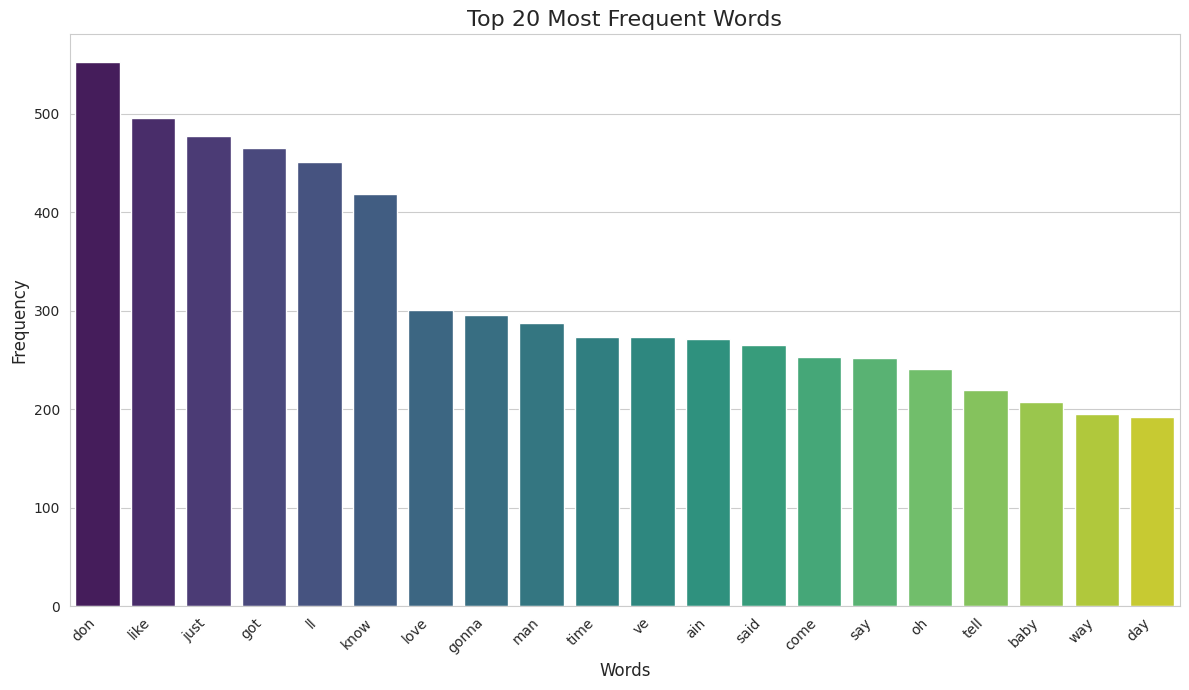

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract words and counts from the sorted_word_count list
words = [item[0] for item in sorted_word_count[:top_n_words]]
counts = [item[1] for item in sorted_word_count[:top_n_words]]

# Create a DataFrame for easier plotting with seaborn
most_frequent_words_df = pd.DataFrame({'Word': words, 'Count': counts})

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Word', y='Count', data=most_frequent_words_df, palette='viridis')
plt.title('Top 20 Most Frequent Words', fontsize=16)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

### TF-IDF: Weighing Word Importance

TF-IDF stands for term frequency-inverse document frequency. It gives higher scores to words that appear often in a particular document but not too often across the entire collection. This helps reduce the influence of common words and highlight words that are more distinctive for a song.

In practice, TF-IDF is often more useful than raw word counts for comparing documents because it balances local importance with overall rarity.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words='english')
X_tfidf = tfidf_vectorizer.fit_transform(corpus)

print(X_tfidf.shape)


(345, 7326)


### Clustering: Grouping Similar Songs

With the numeric representations, you can now perform clustering to group similar songs.

**K-means** is a popular algorithm that can partition a set of data points into K groups, where K is predefined.

In [20]:
from sklearn.cluster import KMeans

# Using TF-IDF vectors for clustering
kmeans = KMeans(n_clusters=5, random_state=0)  # Assuming we want to cluster into 5 groups
kmeans.fit(X_tfidf)

# Print cluster labels for each song
print(kmeans.labels_)

# Count the number of songs in each cluster (from KMeans)
cluster_counts = np.bincount(kmeans.labels_)

print("KMeans Cluster Sizes:")
for i, count in enumerate(cluster_counts):
    print(f"Cluster {i}: {count} songs")

[3 4 3 3 4 1 3 3 3 4 3 2 2 3 1 3 3 3 4 3 1 3 3 1 1 4 4 4 4 3 4 3 3 4 0 3 4
 1 1 0 1 3 3 3 3 1 0 3 1 4 3 3 1 3 2 1 3 3 3 3 3 3 4 0 1 3 4 1 1 1 3 1 4 3
 4 1 3 2 3 4 3 1 3 1 1 3 0 2 3 4 1 4 3 2 4 4 3 1 1 2 4 3 3 1 1 2 0 3 3 3 3
 4 4 0 4 4 3 3 3 2 0 3 0 4 4 0 1 1 2 3 3 0 3 3 3 3 1 3 0 3 1 1 3 2 3 3 1 2
 1 2 1 1 3 0 4 2 4 4 1 0 3 3 3 1 1 3 0 3 0 4 1 4 4 1 3 3 3 4 1 3 4 4 0 2 4
 3 4 2 4 0 1 3 3 1 4 1 3 1 3 1 3 1 1 0 4 3 1 1 3 1 4 1 3 2 1 0 2 3 1 1 1 0
 3 3 4 1 3 3 0 3 3 3 0 2 3 2 1 3 1 3 1 1 4 3 4 3 1 1 1 3 2 3 3 3 0 3 0 4 1
 3 3 3 1 4 1 1 1 3 4 4 3 3 4 3 3 3 1 3 3 4 3 0 4 3 3 3 3 3 2 3 3 2 3 3 3 3
 3 3 3 4 3 1 3 3 3 3 3 3 1 3 1 1 3 1 3 1 2 1 3 3 3 3 1 1 3 3 3 3 3 2 3 4 3
 1 1 1 4 2 3 3 3 3 3 2 3]
KMeans Cluster Sizes:
Cluster 0: 26 songs
Cluster 1: 82 songs
Cluster 2: 27 songs
Cluster 3: 154 songs
Cluster 4: 56 songs


**Hierarchical Clustering** is a different algorithm that agglomeratively groups similar objects into clusters, eventually forming a tree (hierarchy) of clusters.

Visualizing Clusters as a Tree (Dendrogram using Hierarchical Clustering):


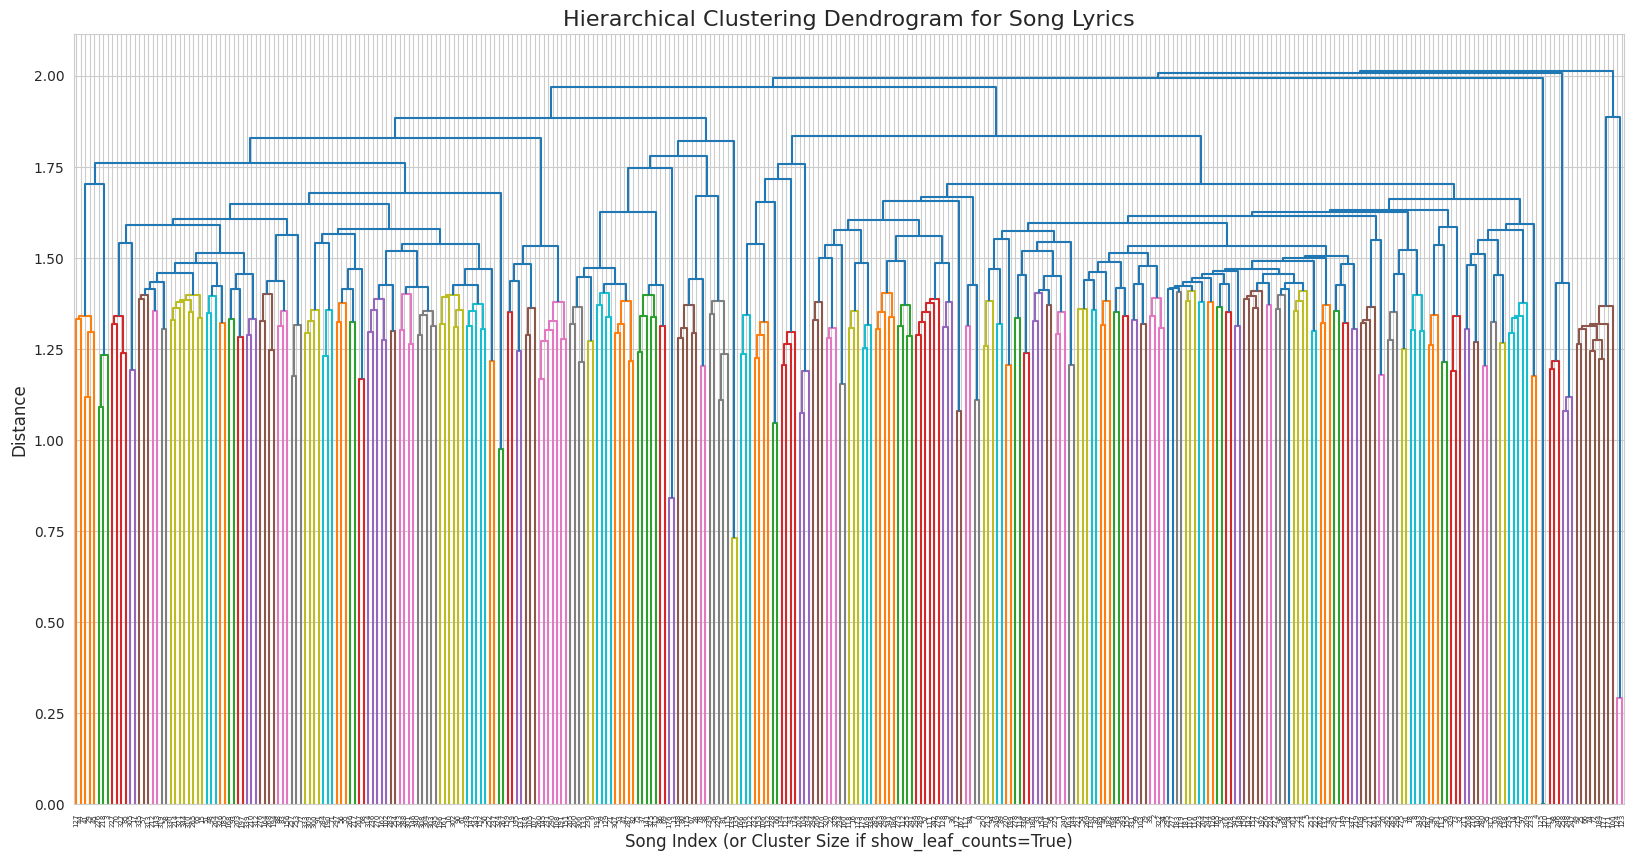

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

print("Visualizing Clusters as a Tree (Dendrogram using Hierarchical Clustering):")

# Perform hierarchical clustering on the TF-IDF vectors
# 'ward' linkage minimizes the variance of the clusters being merged.
# You can choose other methods like 'complete', 'average', 'single'.
linked = linkage(X_tfidf.toarray(), 'ward')

# Plot the dendrogram
plt.figure(figsize=(20, 10))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram for Song Lyrics', fontsize=16)
plt.xlabel('Song Index (or Cluster Size if show_leaf_counts=True)', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.show()

### Create a Word Cloud

A word cloud is a quick visual summary of common words. It is easy to read, but it should be treated as exploratory rather than analytical because it does not show exact counts or account for context.

In [22]:
# Install wordcloud package
#!pip install --upgrade wordcloud
!pip install --upgrade Wordcloud

In [23]:
# You may need to run this too.
!pip install --upgrade Pillow



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 23.9 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.


In [1]:
# To address the ImportError, we need to install a compatible version of Pillow.
# The error `ImportError: cannot import name '_Ink' from 'PIL._typing'` often indicates
# an incompatibility between wordcloud and a recently upgraded Pillow version.
# Downgrading Pillow to a known working version, like 9.5.0, usually resolves this.
!pip install Pillow==9.5.0

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all the text in the 'title' column into a single string
all_titles_text = " ".join(title for title in df['title'])

# Generate a word cloud image
wordcloud = WordCloud(background_color='white', width=800, height=400).generate(all_titles_text)

# Display the generated image
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

NameError: name 'df' is not defined

### Sentiment Analysis with a Pre-trained Model

For a simple sentiment analysis, you can use a pre-trained model from libraries such as TextBlob to estimate the sentiment score expressed in text.

TextBlob: https://textblob.readthedocs.io/en/dev/

In [2]:
# Install TextBlob
!pip install textblob

In [4]:
# This example uses TextBlob for sentiment analysis
from textblob import TextBlob

# Sample usage with the first five song's lyrics
for i in range(5):
    title = df['title'].iloc[i]
    lyrics = df['lyrics'].iloc[i]
    blob = TextBlob(lyrics)
    score = blob.sentiment.polarity
    print(f"{title}\t{lyrics[:25]}...\t{score}")

NameError: name 'df' is not defined

## Exercises

Try these exercises to practice adapting the workflow above. Start by writing the code yourself, then compare your result with a partner or instructor.

In [5]:
# Exercise 1: Find the top 10 frequent words in Dylan's songs for each decade.
# Hint: loop through df.groupby('decade'), then fit a CountVectorizer to each decade's lyrics.


top_words_by_decade = df.groupby('decade')['lyrics'].apply(get_top_n_words)

print("Top 10 frequent words for each decade:")
for decade, words in top_words_by_decade.items():
    print(f"\nDecade {decade}s:")
    for word, count in words:
        print(f"  - {word}: {count}")

NameError: name 'df' is not defined

In [6]:
# Exercise 2: Create a boxplot showing sentiment scores across decades.
# Hint: use x='decade' and y='sentiment_polarity' with sns.boxplot().

import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

# Calculate sentiment polarity for each song and store it in a new column
# This might take a moment depending on the number of songs.
print("Calculating sentiment polarity for each song...")
df['sentiment_polarity'] = df['lyrics'].apply(lambda x: TextBlob(x).sentiment.polarity)
print("Sentiment calculation complete.")

# Create the boxplot
plt.figure(figsize=(12, 7))
sns.boxplot(x='decade', y='sentiment_polarity', data=df, palette='viridis')
plt.title('Sentiment Polarity of Songs Across Decades', fontsize=16)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Sentiment Polarity', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Calculating sentiment polarity for each song...


NameError: name 'df' is not defined

## Working with Text Data from an API

Many API responses contain text data. For instance, the [NewsAPI](https://newsapi.org/) searches articles and breaking-news headlines from news sources and blogs across the web.

In this section, we will search recent news articles and convert the results into a DataFrame for text analysis.

To use the NewsAPI, you'll need an API key. It's recommended to store your API key securely in Colab's secrets manager under the "🔑" icon in the left panel. Name the secret `NEWS_API_KEY`.

In [7]:
from google.colab import userdata

NEWS_API_KEY = userdata.get('NEWS_API_Key')
print(f"API Key: {NEWS_API_KEY}")

API Key: 356ffc2bb381405ab515e0ed2d087962


In [8]:
import datetime

# Get today's date
today = datetime.date.today()

# Calculate the date three days ago
three_days_ago = today - datetime.timedelta(days=3)

# Format the date for the API request (YYYY-MM-DD)
from_param = three_days_ago.strftime('%Y-%m-%d')

print(f"Fetching news from: {from_param} to {today.strftime('%Y-%m-%d')}")

Fetching news from: 2026-05-28 to 2026-05-31


In [9]:
import requests
import pandas as pd # Import pandas for DataFrame

query = input("Please enter your search query for news articles: ")
print(f"Searching for articles related to: {query}")

# NewsAPI endpoint for all articles
url = 'https://newsapi.org/v2/everything'

# Parameters for the request
params = {
    'pageSize': 100,    # Max number of articles to retrieve per request for 'everything' endpoint
    'apiKey': NEWS_API_KEY,
    'q': query, # The search query
    'from': from_param, # Start date for the search (already calculated)
    'to': today.strftime('%Y-%m-%d'), # End date for the search (today)
    'language': 'en' # Filter for English language articles
}

try:
    response = requests.get(url, params=params)
    response.raise_for_status() # Raise an exception for HTTP errors
    data = response.json()

    print("Successfully fetched news articles.")

    articles_data = []
    for article in data['articles']:
        source_name = article.get('source', {}).get('name', 'N/A')
        articles_data.append({
            'title': article.get('title'),
            'author': article.get('author'),
            'source': source_name,
            'description': article.get('description'),
            'date': article.get('publishedAt')
        })

    news_df = pd.DataFrame(articles_data)

    print(f"Total articles retrieved and saved to DataFrame: {len(news_df)}")
    print(f"Total results matching query (available from API): {data['totalResults']}")
    display(news_df.head(20  ))

except requests.exceptions.RequestException as e:
    print(f"Error fetching news: {e}")
    if response.status_code == 401:
        print("Unauthorized: Check your API key.")
    elif response.status_code == 429:
        print("Too Many Requests: You may have hit your API rate limit.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Please enter your search query for news articles: Trump 
Searching for articles related to: Trump 
Successfully fetched news articles.
Total articles retrieved and saved to DataFrame: 100
Total results matching query (available from API): 4817


,title,author,source,description,date
0,Does the US need new laws to protect elections?,None,BBC News,"And, why does Donald Trump want to “nationalis...",2026-05-29T16:36:00Z
1,US judge orders Trump's name be removed from K...,None,BBC News,The performing arts centre must also remain op...,2026-05-29T21:02:22Z
2,US carries out new strikes on Iran military site,None,BBC News,The latest wave of attacks comes as President ...,2026-05-28T01:07:36Z
3,Former US attorney general Pam Bondi testifies...,None,BBC News,The testimony comes about a month after Americ...,2026-05-29T13:17:19Z
4,I downloaded the Trump Accounts app for my new...,Mia de Graaf,Business Insider,"I had my daughter in January 2026, so she is e...",2026-05-29T08:34:50Z
5,"Trump pledged to house 6,000 homeless vets. Hi...",Quil Lawrence,NPR,Veteran groups hoped a Trump executive order w...,2026-05-28T09:00:00Z
6,Morning news brief,A Martínez,NPR,The U.S. says it's moving closer to a deal to ...,2026-05-29T08:47:36Z
7,Trump wants a gas tax holiday. There's a much ...,Camila Domonoske,NPR,Suspending the federal gasoline tax could save...,2026-05-28T09:00:00Z
8,Reid Hoffman says reported DOJ investigation i...,Ben Shimkus,Business Insider,Reid Hoffman posted on X in response to report...,2026-05-29T17:28:56Z
9,Trump's name must come off of the Kennedy Cent...,Anastasia Tsioulcas,NPR,The judge wrote in his 94-page ruling that it ...,2026-05-29T20:33:21Z


### Analyze the Text in the News Articles

What questions can we ask about this dataset?

- Which words appear most often in article titles or descriptions?
- Do different sources use different language for the same topic?
- How does sentiment vary across articles or sources?
- Are there clusters of articles that focus on different subtopics?

In [13]:


news_df['combined_text'] = news_df['title'].fillna('') + ' ' + news_df['description'].fillna('')


vectorizer_news = CountVectorizer(stop_words='english')


X_news = vectorizer_news.fit_transform(news_df['combined_text'])


word_counts_news = np.sum(X_news.toarray(), axis=0)


feature_words_news = vectorizer_news.get_feature_names_out()


word_count_dict_news = {word: int(count) for word, count in zip(feature_words_news, word_counts_news)}


sorted_word_count_news = sorted(word_count_dict_news.items(), key=lambda x: x[1], reverse=True)


top_n_words_news = 20
print(f"Top {top_n_words_news} most frequent words in news article titles and descriptions:")
for word, count in sorted_word_count_news[:top_n_words_news]:
    print(f"  - {word}: {count}")


Top 20 most frequent words in news article titles and descriptions:
  - trump: 100
  - iran: 21
  - president: 19
  - judge: 14
  - 250: 13
  - donald: 13
  - deal: 12
  - says: 12
  - center: 11
  - senate: 11
  - kennedy: 9
  - war: 9
  - administration: 8
  - doj: 8
  - federal: 8
  - fund: 8
  - jean: 8
  - new: 8
  - american: 7
  - carroll: 7


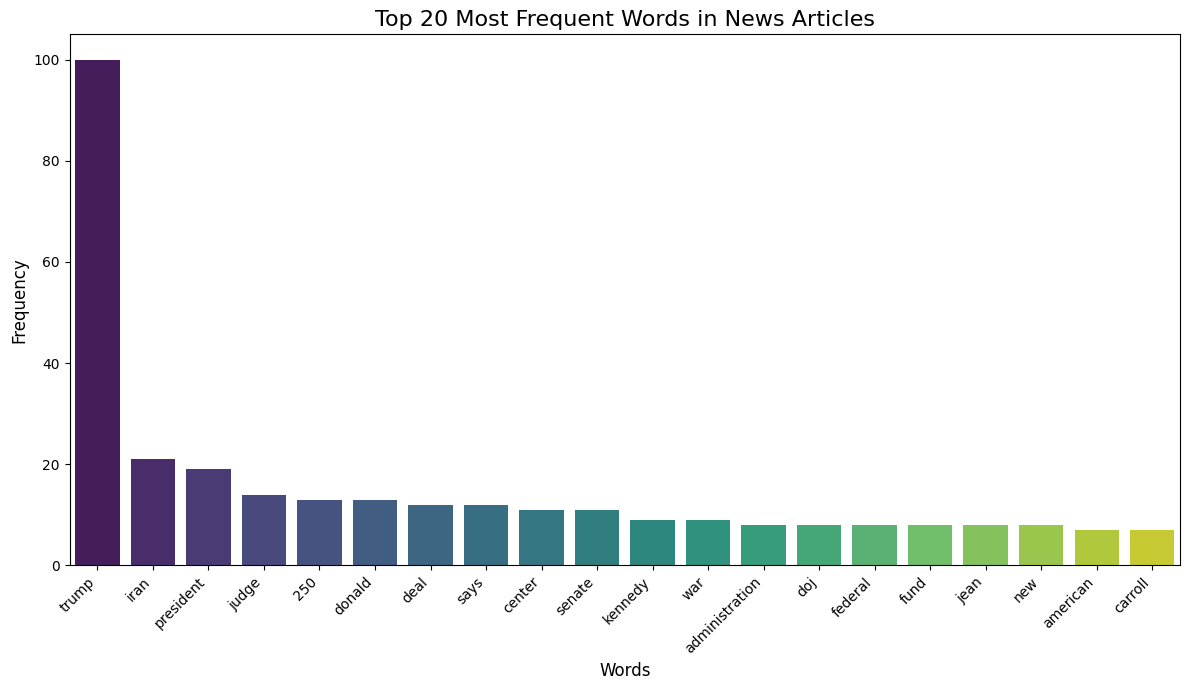

In [14]:

words_plot = [item[0] for item in sorted_word_count_news[:top_n_words_news]]
counts_plot = [item[1] for item in sorted_word_count_news[:top_n_words_news]]


most_frequent_words_df_news = pd.DataFrame({'Word': words_plot, 'Count': counts_plot})


plt.figure(figsize=(12, 7))
sns.barplot(x='Word', y='Count', data=most_frequent_words_df_news, palette='viridis', hue='Word', legend=False)
plt.title('Top 20 Most Frequent Words in News Articles', fontsize=16)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [16]:

source_counts = news_df['source'].value_counts()
print("Top 5 news sources by article count:")
display(source_counts.head())


source_combined_text = news_df.groupby('source')['combined_text'].apply(lambda x: ' '.join(x))


tfidf_vectorizer_source = TfidfVectorizer(stop_words='english')


top_words_by_source = {}


for source_name, text in source_combined_text.items():

    X_tfidf_source = tfidf_vectorizer_source.fit_transform([text])


    feature_names = tfidf_vectorizer_source.get_feature_names_out()


    tfidf_scores = X_tfidf_source.toarray().flatten()


    word_scores = pd.DataFrame({'word': feature_names, 'tfidf': tfidf_scores})


    top_n = 10
    top_words = word_scores.sort_values(by='tfidf', ascending=False).head(top_n)
    top_words_by_source[source_name] = top_words


print("\nTop 10 most distinctive words for selected news sources:")
for source in source_counts.head(5).index:
    if source in top_words_by_source:
        print(f"\n--- Source: {source} ---")
        display(top_words_by_source[source])


Top 5 news sources by article count:


,count
source,
Yahoo Entertainment,37
Abcnews.com,13
NPR,10
Boing Boing,8
BBC News,5



Top 10 most distinctive words for selected news sources:

--- Source: Yahoo Entertainment ---


,word,tfidf
316,trump,0.791033
231,president,0.138431
161,iran,0.138431
167,judge,0.118655
274,says,0.118655
89,deal,0.118655
103,donald,0.098879
2,250,0.098879
326,washington,0.079103
83,criminal,0.079103



--- Source: Abcnews.com ---


...

,word,tfidf
186,trump,0.263158
68,gas,0.157895
25,center,0.157895
121,party,0.157895
157,says,0.157895
177,swing,0.157895
182,texas,0.157895
89,iran,0.157895
51,doj,0.105263
59,end,0.105263



--- Source: Boing Boing ---


,word,tfidf
186,trump,0.494913
1,250,0.224961
37,center,0.134976
29,board,0.134976
31,brains,0.134976
75,freedom,0.134976
8,american,0.134976
84,grandpa,0.134976
147,pudding,0.134976
151,read,0.134976



--- Source: BBC News ---


,word,tfidf
60,trump,0.507093
28,iran,0.338062
48,president,0.253546
13,comes,0.169031
19,does,0.169031
20,donald,0.169031
16,deal,0.169031
21,elections,0.169031
41,new,0.169031
7,attorney,0.084515


Average Sentiment Polarity by News Source:


,sentiment_polarity
source,
Slate Magazine,0.214286
BBC News,0.133030
Newsnationnow.com,0.125000
The Hill,0.103636
Kotaku,0.100000
Techdirt,0.086111
Gizmodo.com,0.046807
Abcnews.com,0.043298
NPR,0.031825


/tmp/ipykernel_2923/3779615371.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_by_source.index, y=sentiment_by_source.values, palette='coolwarm')


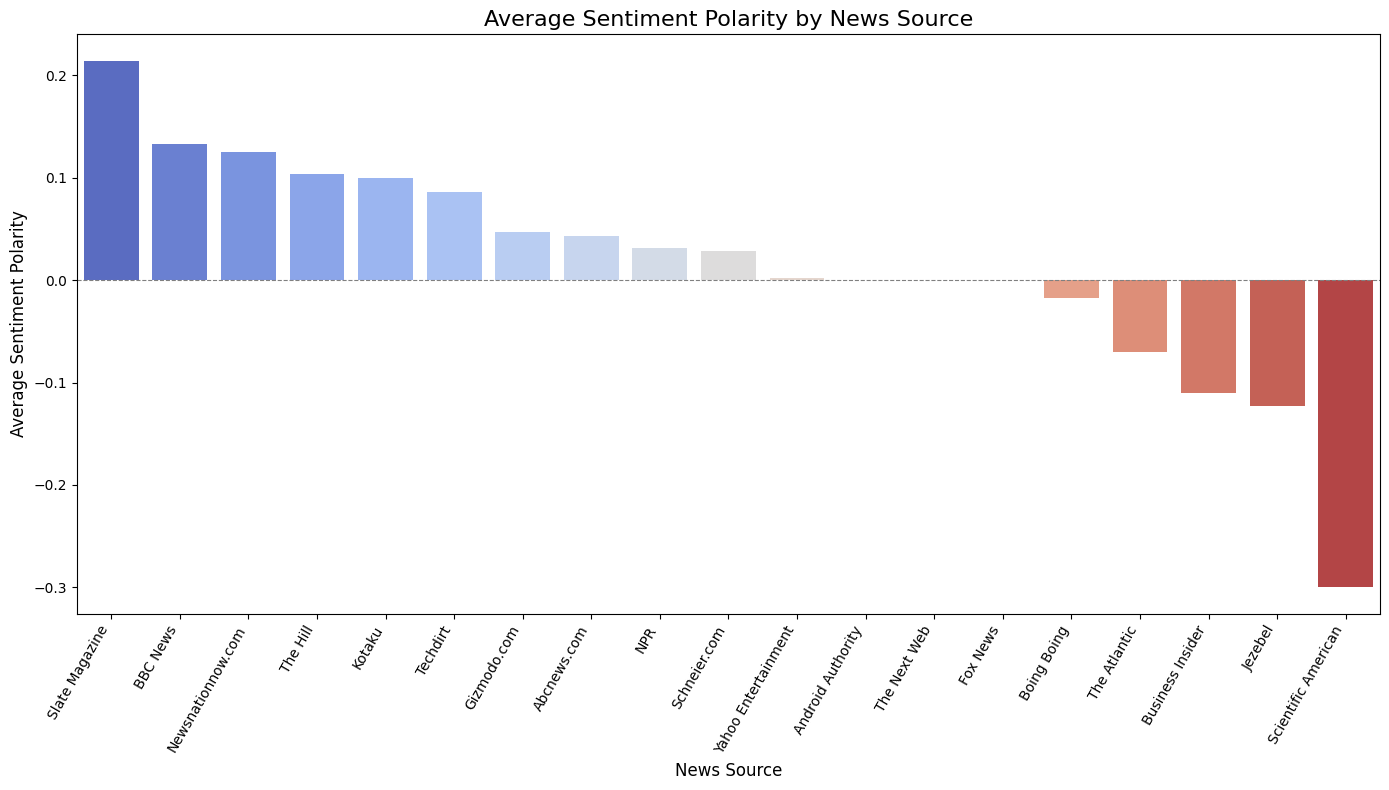

/tmp/ipykernel_2923/3779615371.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='source', y='sentiment_polarity', data=news_df.sort_values(by='sentiment_polarity', ascending=False), palette='coolwarm')


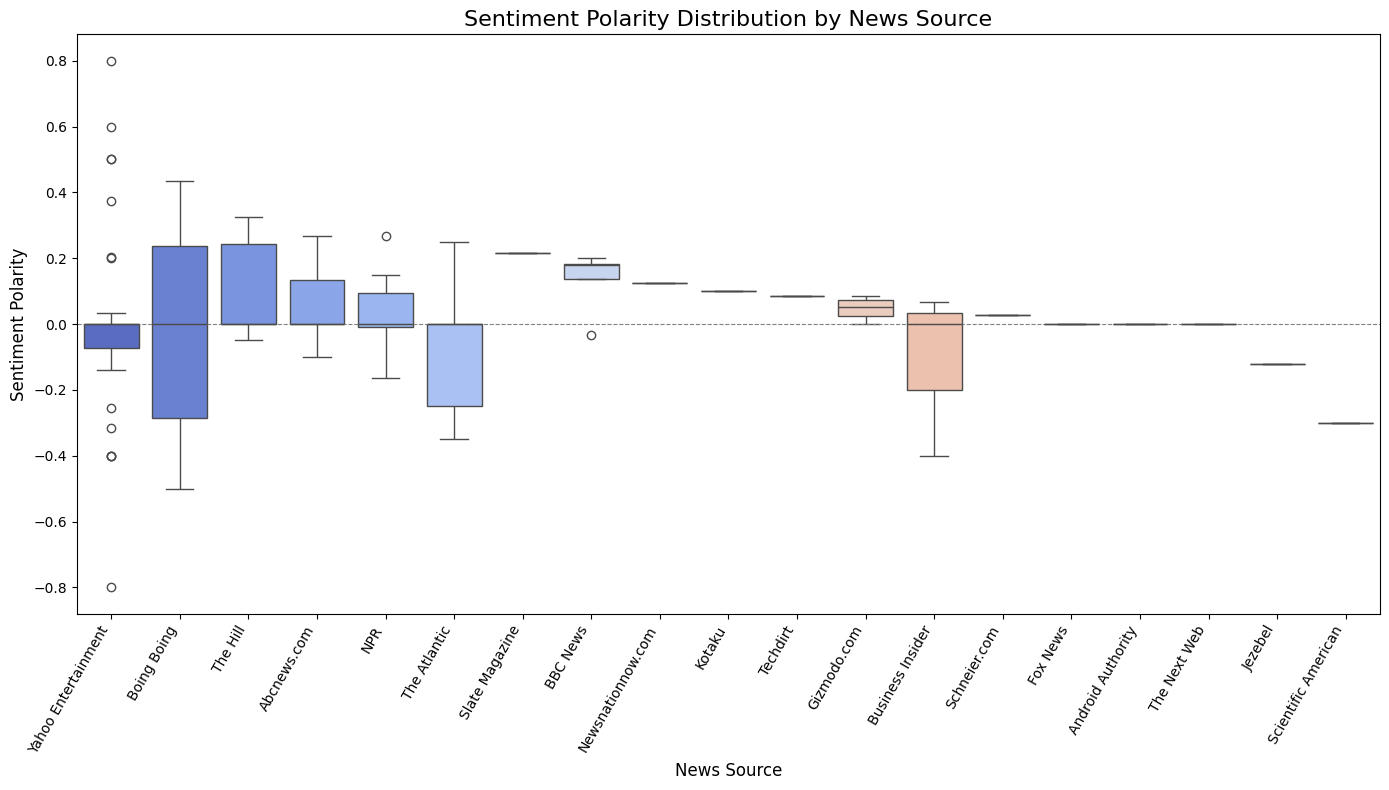

In [18]:

if 'combined_text' not in news_df.columns:
    news_df['combined_text'] = news_df['title'].fillna('') + ' ' + news_df['description'].fillna('')


news_df['sentiment_polarity'] = news_df['combined_text'].apply(lambda x: TextBlob(x).sentiment.polarity)


sentiment_by_source = news_df.groupby('source')['sentiment_polarity'].mean().sort_values(ascending=False)

print("Average Sentiment Polarity by News Source:")
display(sentiment_by_source)


plt.figure(figsize=(14, 8))
sns.barplot(x=sentiment_by_source.index, y=sentiment_by_source.values, palette='coolwarm')
plt.title('Average Sentiment Polarity by News Source', fontsize=16)
plt.xlabel('News Source', fontsize=12)
plt.ylabel('Average Sentiment Polarity', fontsize=12)
plt.xticks(rotation=60, ha='right')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8) # Add a line at 0 for neutrality
plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 8))
sns.boxplot(x='source', y='sentiment_polarity', data=news_df.sort_values(by='sentiment_polarity', ascending=False), palette='coolwarm')
plt.title('Sentiment Polarity Distribution by News Source', fontsize=16)
plt.xlabel('News Source', fontsize=12)
plt.ylabel('Sentiment Polarity', fontsize=12)
plt.xticks(rotation=60, ha='right')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8) # Add a line at 0 for neutrality
plt.tight_layout()
plt.show()

### Clustering Articles into Subtopics

To identify if articles focus on different subtopics, we can use clustering algorithms. K-Means is a popular choice for this. We will apply K-Means to the TF-IDF vectors of the articles to group similar articles together. The number of clusters (k) needs to be chosen; for this analysis, we will start with 5 clusters.

In [22]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

# Ensure TF-IDF vectors are generated (if not already from previous steps)
# The 'corpus' variable should contain the combined text of all articles.
# If 'corpus' is not defined, redefine it:
if 'corpus' not in locals() or corpus is None:
    if 'combined_text' not in news_df.columns:
        news_df['combined_text'] = news_df['title'].fillna('') + ' ' + news_df['description'].fillna('')
    corpus = news_df['combined_text'].dropna().tolist()

# Re-initialize TFIDF vectorizer if needed, or use existing one from previous steps
if 'tfidf_vectorizer_news' not in locals():
    tfidf_vectorizer_news = TfidfVectorizer(stop_words='english')
    X_tfidf = tfidf_vectorizer_news.fit_transform(corpus)

# Set the number of clusters
k = 5 # You can experiment with different values for k

# Perform K-Means clustering
kmeans_model = KMeans(n_clusters=k, init='k-means++', max_iter=300, random_state=42, n_init=10)
kmeans_model.fit(X_tfidf)

# Add cluster labels to the DataFrame
news_df['cluster'] = kmeans_model.labels_

print(f"Clustering complete with {k} clusters. Each article has been assigned a cluster ID.")
print("\nArticles per cluster:")
display(news_df['cluster'].value_counts().sort_index().to_frame())


Clustering complete with 5 clusters. Each article has been assigned a cluster ID.

Articles per cluster:


,count
cluster,
0,6
1,34
2,21
3,6
4,33


In [24]:
print("Top terms per cluster:")
# Ensure kmeans_model and tfidf_vectorizer_news are defined from the previous cell.
# Re-running the previous cell (948aad06) should resolve this issue.
order_centroids = kmeans_model.cluster_centers_.argsort()[:, ::-1]
terms = tfidf_vectorizer_news.get_feature_names_out()

for i in range(k):
    print(f"\nCluster {i}:")
    print("  Top terms:", end='')
    for ind in order_centroids[i, :10]: # Display top 10 terms per cluster
        print(f' {terms[ind]}', end='')
    print()

    # Display some sample article titles for each cluster
    print("  Sample Article Titles:")
    for title in news_df[news_df['cluster'] == i]['title'].head(3):
        print(f"    - {title}")

Top terms per cluster:

Cluster 0:
  Top terms: opinion trump critics republican instead ahead lies lisa murkowski better
  Sample Article Titles:
    - Opinion - What lies ahead for the Republican Party after Trump?
    - Opinion - Trump better watch out for Lisa Murkowski
    - Opinion - Why a Trump enemy could win a solid Republican Florida Senate seat

Cluster 1:
  Top terms: president donald new trump america iran paxton epstein military texas
  Sample Article Titles:
    - Does the US need new laws to protect elections?
    - US carries out new strikes on Iran military site
    - Former US attorney general Pam Bondi testifies in congressional Epstein probe

Cluster 2:
  Top terms: judge trump deal center kennedy fund iran orders anti weaponization
  Sample Article Titles:
    - US judge orders Trump's name be removed from Kennedy Center
    - Trump wants a gas tax holiday. There's a much bigger problem looming
    - Trump's name must come off of the Kennedy Center, judge rules

C

In [1]:


print("Visualizing Clusters as a Tree (Dendrogram using Hierarchical Clustering):")


linked = linkage(X_tfidf.toarray(), 'ward')


plt.figure(figsize=(20, 10))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram for News Articles', fontsize=16)
plt.xlabel('Article Index (or Cluster Size if show_leaf_counts=True)', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.show()

Visualizing Clusters as a Tree (Dendrogram using Hierarchical Clustering):


NameError: name 'linkage' is not defined